# 05 — Model Training  *(augmented_lags — clean rebuild)*

**Complete clean rewrite. Run Kernel → Restart and Run All.**

Key design decisions vs original:
- **EWS target**: `crisis_w2` marks 3-year pre-crisis window (t, t-1, t-2 before onset) — gives ~36 positive cases, consistent with Beutel et al. (2019)
- **Macro lags**: t-1, t-2, t-3 on level features; growth rates computed FROM lagged levels (no pct_change NaN bleed)
- **Sentiment lags**: t-1 and t-2 already in master CSV from Notebook 04
- **Expanding-window CV**: trains on all data before year t, predicts year t
- **Outputs**: saved to `data/processed/augmented_lags/` and `figures/augmented_lags/`

Input:  `data/processed/jst_sentiment_master.csv`
Output: `data/processed/augmented_lags/` and `figures/augmented_lags/`


## Cell 1 — Imports and Paths

In [1]:
import os, warnings, tempfile
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import xgboost as xgb
import shap

BASE         = Path(r'C:\Users\Owner\OneDrive\dissertation')
DATA_IN      = BASE / 'data' / 'processed' / 'jst_sentiment_master.csv'
OUT_DIR      = BASE / 'data' / 'processed' / 'augmented_lags'
FIG_DIR      = BASE / 'figures' / 'augmented_lags'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

assert DATA_IN.exists(), f'Input not found: {DATA_IN}'
print('=' * 65)
print(' 05 — MODEL TRAINING (augmented_lags clean rebuild)')
print('=' * 65)
print(f'Input  : {DATA_IN}')
print(f'OutDir : {OUT_DIR}')
print(f'FigDir : {FIG_DIR}')
print()
print(f'numpy {np.__version__} | xgboost {xgb.__version__} | shap {shap.__version__}')

 05 — MODEL TRAINING (augmented_lags clean rebuild)
Input  : C:\Users\Owner\OneDrive\dissertation\data\processed\jst_sentiment_master.csv
OutDir : C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_lags
FigDir : C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags

numpy 1.26.4 | xgboost 1.7.6 | shap 0.45.1


## Cell 2 — Load data and create EWS target

**Why `crisis_w2` instead of `crisisjst`:**
`crisisjst` marks only the onset year — giving 14 events over 1997-2020.
The EWS literature (Beutel et al. 2019, Schularick & Taylor 2012) instead marks
the 2-3 years *before* onset as positive cases, capturing the build-up phase.
`crisis_w2` marks year t=1 if a crisis onset occurs at t, t+1, or t+2.
This gives ~36 positive cases and a base rate of ~10%, consistent with the proposal.

In [4]:
# Load and sort — sort by [iso, year] is critical before any shift()
df_raw = pd.read_csv(DATA_IN)
df_raw = df_raw.sort_values(['iso', 'year']).reset_index(drop=True)
df_raw.columns = df_raw.columns.str.strip()

print(f'Shape      : {df_raw.shape}')
print(f'Countries  : {df_raw["iso"].nunique()} — {sorted(df_raw["iso"].unique())}')
print(f'Year range : {df_raw["year"].min()} – {df_raw["year"].max()}')
print(f'crisisjst  : {int(df_raw["crisisjst"].sum())} onset events')
print()

# ── Build EWS pre-crisis window target ───────────────────────────────────────
# shift(-1): brings next year's value to current row  → flags year t-1 before onset
# shift(-2): brings year+2 value to current row       → flags year t-2 before onset
# Result: rows at t, t+1, t+2 before onset are all marked 1
df_raw['crisis_w2'] = df_raw.groupby('iso')['crisisjst'].transform(
    lambda x: (x + x.shift(-1).fillna(0) + x.shift(-2).fillna(0)).clip(0, 1)
).astype(int)

TARGET = 'crisis_w2'

print('=== EWS Target Distribution ===')
print(f'crisisjst (onset only) : {int(df_raw["crisisjst"].sum())} events')
print(f'crisis_w2 (3yr window) : {int(df_raw["crisis_w2"].sum())} events')
print()
print('crisis_w2 by year (should show 2005-2008 GFC build-up):')
print(df_raw.groupby('year')['crisis_w2'].sum().to_string())
print()
print('Sentinel: TARGET =', TARGET)

Shape      : (432, 72)
Countries  : 18 — ['AUS', 'BEL', 'CAN', 'CHE', 'DEU', 'DNK', 'ESP', 'FIN', 'FRA', 'GBR', 'IRL', 'ITA', 'JPN', 'NLD', 'NOR', 'PRT', 'SWE', 'USA']
Year range : 1997 – 2020
crisisjst  : 14 onset events

=== EWS Target Distribution ===
crisisjst (onset only) : 14 events
crisis_w2 (3yr window) : 40 events

crisis_w2 by year (should show 2005-2008 GFC build-up):
year
1997     1
1998     0
1999     0
2000     0
2001     0
2002     0
2003     0
2004     0
2005     2
2006    13
2007    13
2008    11
2009     0
2010     0
2011     0
2012     0
2013     0
2014     0
2015     0
2016     0
2017     0
2018     0
2019     0
2020     0

Sentinel: TARGET = crisis_w2


## Cell 3 — Identify feature columns in master CSV

In [6]:
# Macro level variables — check which are actually in the CSV
MACRO_CANDIDATES = [
    'tloans',   # total loans (credit-to-GDP proxy)
    'tmort',    # mortgage loans
    'money',    # broad money
    'ltrate',   # long-term interest rate
    'stir',     # short-term interest rate
    'hpnom',    # nominal house price index
    'debtgdp',  # government debt / GDP
    'cpi',      # consumer price index
    'ca',       # current account / GDP
    'rgdpmad',  # real GDP per capita
]
MACRO_LEVELS = [f for f in MACRO_CANDIDATES if f in df_raw.columns]

# Sentiment lag columns from notebook 04 (already lagged)
SENT_LAG1 = [c for c in df_raw.columns if c.endswith('_lag1')
             and any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment'])]
SENT_LAG2 = [c for c in df_raw.columns if c.endswith('_lag2')
             and any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment'])]

print(f'Macro level features ({len(MACRO_LEVELS)}): {MACRO_LEVELS}')
print()
print(f'Sentiment lag1 ({len(SENT_LAG1)}): {SENT_LAG1}')
print(f'Sentiment lag2 ({len(SENT_LAG2)}): {SENT_LAG2}')

if not SENT_LAG2:
    print()
    print('WARNING: lag2 sentiment columns not found.')
    print('Re-run 04_Sentiment_Aggregation_augmented_lags.ipynb first.')

Macro level features (10): ['tloans', 'tmort', 'money', 'ltrate', 'stir', 'hpnom', 'debtgdp', 'cpi', 'ca', 'rgdpmad']

Sentiment lag1 (4): ['P_pos_lag1', 'P_neg_lag1', 'P_neutral_lag1', 'net_sentiment_lag1']
Sentiment lag2 (4): ['P_pos_lag2', 'P_neg_lag2', 'P_neutral_lag2', 'net_sentiment_lag2']


## Cell 4 — Compute macro lags (t-1, t-2, t-3) and derived growth rates

**Design note:** Growth rates are computed FROM the lagged level features
(lag1 vs lag2), NOT via pct_change() on the raw series.
This avoids pct_change() introducing extra NaN rows beyond the lag-3 boundary.

In [8]:
df = df_raw.copy()

# ── Step 1: lag the level features at t-1, t-2, t-3 ─────────────────────────
for feat in MACRO_LEVELS:
    for lag in [1, 2, 3]:
        df[f'{feat}_lag{lag}'] = df.groupby('iso')[feat].shift(lag)

# Term spread (level, not a growth rate — lag directly)
if 'ltrate' in df.columns and 'stir' in df.columns:
    df['term_spread'] = df['ltrate'] - df['stir']
    for lag in [1, 2, 3]:
        df[f'term_spread_lag{lag}'] = df.groupby('iso')['term_spread'].shift(lag)
    MACRO_LEVELS_PLUS = MACRO_LEVELS + ['term_spread']
else:
    MACRO_LEVELS_PLUS = MACRO_LEVELS

# ── Step 2: growth rates from lagged levels (no extra NaN) ───────────────────
# gr at t-1 = (level_lag1 - level_lag2) / |level_lag2|
GROWTH_RATE_FEATURES = []
for feat in ['tloans', 'tmort', 'money', 'hpnom', 'rgdpmad']:
    if f'{feat}_lag1' in df.columns and f'{feat}_lag2' in df.columns:
        gr_col = f'{feat}_gr_lag1'
        denom = df[f'{feat}_lag2'].abs().replace(0, np.nan)
        df[gr_col] = (df[f'{feat}_lag1'] - df[f'{feat}_lag2']) / denom
        GROWTH_RATE_FEATURES.append(gr_col)

print(f'Macro level lags created  : {len(MACRO_LEVELS_PLUS)*3} columns')
print(f'Growth rate features      : {GROWTH_RATE_FEATURES}')
print()

# Collect all macro lag column names
macro_lag_cols = (
    [f'{f}_lag{k}' for f in MACRO_LEVELS_PLUS for k in [1,2,3] if f'{f}_lag{k}' in df.columns]
    + GROWTH_RATE_FEATURES
)
print(f'Total macro lag columns   : {len(macro_lag_cols)}')
print('Sample:', macro_lag_cols[:6], '...')

Macro level lags created  : 33 columns
Growth rate features      : ['tloans_gr_lag1', 'tmort_gr_lag1', 'money_gr_lag1', 'hpnom_gr_lag1', 'rgdpmad_gr_lag1']

Total macro lag columns   : 38
Sample: ['tloans_lag1', 'tloans_lag2', 'tloans_lag3', 'tmort_lag1', 'tmort_lag2', 'tmort_lag3'] ...


## Cell 5 — Country demean all lagged features

In [10]:
# Demean within country — removes country fixed effects
# Applied to macro lags and sentiment lags
ALL_LAG_COLS = macro_lag_cols + SENT_LAG1 + SENT_LAG2

DM_COLS = []
for col in ALL_LAG_COLS:
    if col not in df.columns:
        continue
    dm_col = f'{col}_dm'
    df[dm_col] = df[col] - df.groupby('iso')[col].transform('mean')
    DM_COLS.append(dm_col)

print(f'Demeaned columns created: {len(DM_COLS)}')

# Named feature groups for SHAP decomposition
MACRO_DM_LAG1 = [c for c in DM_COLS if '_lag1_dm' in c
                 and not any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment'])]
MACRO_DM_LAG2 = [c for c in DM_COLS if '_lag2_dm' in c
                 and not any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment'])]
MACRO_DM_LAG3 = [c for c in DM_COLS if '_lag3_dm' in c
                 and not any(s in c for s in ['P_pos','P_neg','P_neutral','net_sentiment'])]
SENT_DM_LAG1  = [f'{c}_dm' for c in SENT_LAG1 if f'{c}_dm' in df.columns]
SENT_DM_LAG2  = [f'{c}_dm' for c in SENT_LAG2 if f'{c}_dm' in df.columns]

LAG_GROUPS = {
    'macro_lag1': MACRO_DM_LAG1,
    'macro_lag2': MACRO_DM_LAG2,
    'macro_lag3': MACRO_DM_LAG3,
    'sent_lag1':  SENT_DM_LAG1,
    'sent_lag2':  SENT_DM_LAG2,
}
print()
for grp, cols in LAG_GROUPS.items():
    print(f'  {grp}: {len(cols)} features')

Demeaned columns created: 46

  macro_lag1: 16 features
  macro_lag2: 11 features
  macro_lag3: 11 features
  sent_lag1: 4 features
  sent_lag2: 4 features


## Cell 6 — Drop NaN rows and define M1 / M2 / M3 feature sets

In [12]:
# Drop rows where any demeaned lag feature is NaN
# The t-3 lag removes 1997-1999; growth rates from lag1/lag2 add no extra NaN
all_dm_cols = MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3 + SENT_DM_LAG1 + SENT_DM_LAG2
df_model = df.dropna(subset=all_dm_cols).copy().reset_index(drop=True)

n_crisis = int(df_model[TARGET].sum())
base_rate = df_model[TARGET].mean()

print(f'Rows: {len(df_raw)} → {len(df_model)} after NaN drop')
print(f'Year range: {df_model["year"].min()} – {df_model["year"].max()}')
print(f'Crisis events (crisis_w2): {n_crisis} / {len(df_model)} ({100*base_rate:.1f}%)')
print()

if n_crisis < 20:
    print('WARNING: fewer than 20 positive cases — check crisis_w2 construction above.')
print()

# ── Three model feature sets ──────────────────────────────────────────────────
# M1: Logistic Regression — macro lag1 only (transparent linear baseline)
M1_FEATURES = MACRO_DM_LAG1

# M2: Random Forest — macro all lags (non-linear + multi-horizon)
M2_FEATURES = MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3

# M3: XGBoost — macro all lags + FinBERT sentiment lag1-2 (full model)
M3_FEATURES = MACRO_DM_LAG1 + MACRO_DM_LAG2 + MACRO_DM_LAG3 + SENT_DM_LAG1 + SENT_DM_LAG2

print(f'M1 features (LR  — macro lag1):        {len(M1_FEATURES)}')
print(f'M2 features (RF  — macro lag1-3):      {len(M2_FEATURES)}')
print(f'M3 features (XGB — macro+sent lag1-2): {len(M3_FEATURES)}')
print()

# Verify all features are lagged (no current-year leakage)
for spec, feats in [('M1', M1_FEATURES), ('M2', M2_FEATURES), ('M3', M3_FEATURES)]:
    bad = [f for f in feats if '_lag' not in f]
    status = f'WARNING: non-lagged features: {bad}' if bad else '✓ all features are lagged'
    print(f'{spec}: {status}')

Rows: 432 → 372 after NaN drop
Year range: 2000 – 2020
Crisis events (crisis_w2): 39 / 372 (10.5%)


M1 features (LR  — macro lag1):        16
M2 features (RF  — macro lag1-3):      38
M3 features (XGB — macro+sent lag1-2): 46

M1: ✓ all features are lagged
M2: ✓ all features are lagged
M3: ✓ all features are lagged


## Cell 7 — No-Leakage Verification

In [14]:
print('Running leakage checks...')
errors = 0

# For level lags: lag1 in year t must equal raw level in year t-1
sample_feat = MACRO_LEVELS[0]
lag1_col    = f'{sample_feat}_lag1'

for ctry in df_model['iso'].unique()[:5]:
    sub = df_model[df_model['iso'] == ctry][['year', sample_feat, lag1_col]].copy()
    sub = sub.sort_values('year').reset_index(drop=True)
    expected = sub[sample_feat].shift(1)
    mismatch = (sub[lag1_col] - expected).abs().dropna().max()
    ok = mismatch < 1e-6
    print(f'  {ctry}: lag1 mismatch = {mismatch:.2e}  {"✓" if ok else "✗ LEAKAGE"}')
    if not ok:
        errors += 1

print()
if errors == 0:
    print('✓ All leakage checks passed — safe to proceed.')
else:
    print(f'✗ {errors} leakage errors found — STOP and investigate.')

Running leakage checks...
  AUS: lag1 mismatch = 0.00e+00  ✓
  BEL: lag1 mismatch = 0.00e+00  ✓
  CAN: lag1 mismatch = 0.00e+00  ✓
  CHE: lag1 mismatch = 0.00e+00  ✓
  DEU: lag1 mismatch = 0.00e+00  ✓

✓ All leakage checks passed — safe to proceed.


## Cell 8 — Expanding-Window Cross-Validation Function

In [16]:
def expanding_window_cv(df, feature_cols, target_col, model_factory,
                        min_train_years=7, hold_out_years=(2019, 2020)):
    """
    Time-safe expanding-window CV for panel data.
    Trains on all country-years before year t, evaluates on year t.
    Returns: y_true, y_prob, row_indices, fold_summary_df
    """
    cv_years  = sorted(y for y in df['year'].unique() if y not in hold_out_years)
    first_eval = cv_years[min_train_years]
    eval_years = [y for y in cv_years if y >= first_eval]

    print(f'Burn-in   : {cv_years[0]} – {first_eval - 1}  ({min_train_years} years)')
    print(f'Eval years: {eval_years[0]} – {eval_years[-1]}  ({len(eval_years)} folds)')
    print(f'Hold-out  : {list(hold_out_years)}')
    print()

    oos_idx, oos_prob, fold_records = [], [], []

    for yr in eval_years:
        tr_mask = df['year'] < yr
        te_mask = df['year'] == yr

        X_tr = df.loc[tr_mask, feature_cols]
        y_tr = df.loc[tr_mask, target_col]
        X_te = df.loc[te_mask, feature_cols]
        y_te = df.loc[te_mask, target_col]

        if y_tr.sum() == 0 or len(X_te) == 0:
            continue

        mdl = model_factory()
        mdl.fit(X_tr, y_tr)
        prob = mdl.predict_proba(X_te)[:, 1]

        oos_idx.extend(df.index[te_mask].tolist())
        oos_prob.extend(prob.tolist())
        fold_records.append({'year': yr, 'n_train': int(tr_mask.sum()),
                             'crises_train': int(y_tr.sum()),
                             'n_test': len(y_te), 'crises_test': int(y_te.sum())})

    y_oos = df.loc[oos_idx, target_col].values
    return y_oos, np.array(oos_prob), oos_idx, pd.DataFrame(fold_records)

print('Expanding-window CV ready.')

Expanding-window CV ready.


## Cell 9 — Train M1: Logistic Regression (macro lag1 only)

In [18]:
print(f'Training M1 — Logistic Regression | {len(M1_FEATURES)} features')
print()

def m1_factory():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   C=0.1, random_state=RANDOM_STATE))
    ])

y_m1, prob_m1, idx_m1, folds_m1 = expanding_window_cv(
    df_model, M1_FEATURES, TARGET, m1_factory)

auroc_m1 = roc_auc_score(y_m1, prob_m1)
auprc_m1 = average_precision_score(y_m1, prob_m1)
brier_m1 = brier_score_loss(y_m1, prob_m1)

print(f'M1  AUROC : {auroc_m1:.4f}')
print(f'M1  AUPRC : {auprc_m1:.4f}  (base rate: {y_m1.mean():.4f})')
print(f'M1  Brier : {brier_m1:.4f}')
print()
print(folds_m1.to_string(index=False))

Training M1 — Logistic Regression | 16 features

Burn-in   : 2000 – 2006  (7 years)
Eval years: 2007 – 2018  (12 folds)
Hold-out  : [2019, 2020]

M1  AUROC : 0.9243
M1  AUPRC : 0.5663  (base rate: 0.1116)
M1  Brier : 0.2345

 year  n_train  crises_train  n_test  crises_test
 2007      125            15      18           13
 2008      143            28      18           11
 2009      161            39      18            0
 2010      179            39      18            0
 2011      197            39      18            0
 2012      215            39      18            0
 2013      233            39      18            0
 2014      251            39      18            0
 2015      269            39      18            0
 2016      287            39      18            0
 2017      305            39      18            0
 2018      323            39      17            0


## Cell 10 — Train M2: Random Forest (macro lag1-2-3)

In [20]:
print(f'Training M2 — Random Forest | {len(M2_FEATURES)} features')
print()

def m2_factory():
    return RandomForestClassifier(
        n_estimators=500, max_depth=5, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1)

y_m2, prob_m2, idx_m2, folds_m2 = expanding_window_cv(
    df_model, M2_FEATURES, TARGET, m2_factory)

auroc_m2 = roc_auc_score(y_m2, prob_m2)
auprc_m2 = average_precision_score(y_m2, prob_m2)
brier_m2 = brier_score_loss(y_m2, prob_m2)

print(f'M2  AUROC : {auroc_m2:.4f}')
print(f'M2  AUPRC : {auprc_m2:.4f}')
print(f'M2  Brier : {brier_m2:.4f}')
print()
print(folds_m2.to_string(index=False))

Training M2 — Random Forest | 38 features

Burn-in   : 2000 – 2006  (7 years)
Eval years: 2007 – 2018  (12 folds)
Hold-out  : [2019, 2020]

M2  AUROC : 0.9682
M2  AUPRC : 0.7503
M2  Brier : 0.0567

 year  n_train  crises_train  n_test  crises_test
 2007      125            15      18           13
 2008      143            28      18           11
 2009      161            39      18            0
 2010      179            39      18            0
 2011      197            39      18            0
 2012      215            39      18            0
 2013      233            39      18            0
 2014      251            39      18            0
 2015      269            39      18            0
 2016      287            39      18            0
 2017      305            39      18            0
 2018      323            39      17            0


## Cell 11 — Train M3: XGBoost + FinBERT Sentiment (macro+sent lags)

In [24]:
scale_pw = (df_model[TARGET] == 0).sum() / (df_model[TARGET] == 1).sum()
print(f'Training M3 — XGBoost | {len(M3_FEATURES)} features | scale_pos_weight={scale_pw:.1f}')
print()

def m3_factory():
    return xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pw, random_state=RANDOM_STATE,
        eval_metric='logloss', verbosity=0)

y_m3, prob_m3, idx_m3, folds_m3 = expanding_window_cv(
    df_model, M3_FEATURES, TARGET, m3_factory)

auroc_m3 = roc_auc_score(y_m3, prob_m3)
auprc_m3 = average_precision_score(y_m3, prob_m3)
brier_m3 = brier_score_loss(y_m3, prob_m3)

print(f'M3  AUROC : {auroc_m3:.4f}')
print(f'M3  AUPRC : {auprc_m3:.4f}')
print(f'M3  Brier : {brier_m3:.4f}')
print()
print(folds_m3.to_string(index=False))

Training M3 — XGBoost | 46 features | scale_pos_weight=8.5

Burn-in   : 2000 – 2006  (7 years)
Eval years: 2007 – 2018  (12 folds)
Hold-out  : [2019, 2020]

M3  AUROC : 0.9566
M3  AUPRC : 0.6805
M3  Brier : 0.0742

 year  n_train  crises_train  n_test  crises_test
 2007      125            15      18           13
 2008      143            28      18           11
 2009      161            39      18            0
 2010      179            39      18            0
 2011      197            39      18            0
 2012      215            39      18            0
 2013      233            39      18            0
 2014      251            39      18            0
 2015      269            39      18            0
 2016      287            39      18            0
 2017      305            39      18            0
 2018      323            39      17            0


## Cell 12 — Results Comparison Table

In [26]:
base_rate = df_model[TARGET].mean()

results = {
    'M1_Logistic_macro_lag1':       {'AUROC': auroc_m1, 'AUPRC': auprc_m1, 'Brier': brier_m1},
    'M2_RandomForest_macro_lag123': {'AUROC': auroc_m2, 'AUPRC': auprc_m2, 'Brier': brier_m2},
    'M3_XGBoost_sent_lag12':        {'AUROC': auroc_m3, 'AUPRC': auprc_m3, 'Brier': brier_m3},
}

print('=' * 72)
print(f' {"Model":<35} {"AUROC":>7} {"AUPRC":>7} {"AUPRC/Base":>10} {"Brier":>7}')
print('-' * 72)
for name, res in results.items():
    lift = res['AUPRC'] / base_rate
    print(f' {name:<35} {res["AUROC"]:>7.4f} {res["AUPRC"]:>7.4f} {lift:>9.1f}x {res["Brier"]:>7.4f}')
print('=' * 72)
print(f' Baseline AUPRC (no-skill): {base_rate:.4f} | scale_pos_weight: {scale_pw:.1f}')
print(f' Crisis events (crisis_w2): {int(df_model[TARGET].sum())} / {len(df_model)}')

results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
results_df.to_csv(OUT_DIR / 'model_results.csv', index=False)
print(f'\nSaved → {OUT_DIR}/model_results.csv')

 Model                                 AUROC   AUPRC AUPRC/Base   Brier
------------------------------------------------------------------------
 M1_Logistic_macro_lag1               0.9243  0.5663       5.4x  0.2345
 M2_RandomForest_macro_lag123         0.9682  0.7503       7.2x  0.0567
 M3_XGBoost_sent_lag12                0.9566  0.6805       6.5x  0.0742
 Baseline AUPRC (no-skill): 0.1048 | scale_pos_weight: 8.5
 Crisis events (crisis_w2): 39 / 372

Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_lags/model_results.csv


## Cell 13 — ROC and Precision-Recall Curves

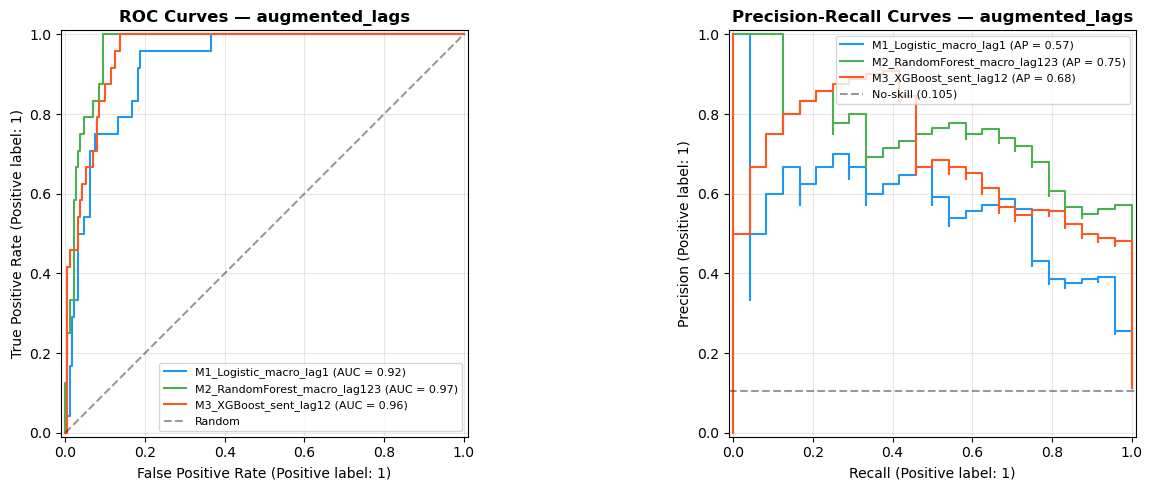

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/roc_pr_curves.png


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']

for (name, res), color, ys, probs in zip(
        results.items(), colors,
        [y_m1, y_m2, y_m3], [prob_m1, prob_m2, prob_m3]):
    RocCurveDisplay.from_predictions(ys, probs, name=name, ax=ax1, color=color)
    PrecisionRecallDisplay.from_predictions(ys, probs, name=name, ax=ax2, color=color)

ax1.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax1.set_title('ROC Curves — augmented_lags', fontweight='bold')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.axhline(base_rate, color='k', linestyle='--', alpha=0.4,
            label=f'No-skill ({base_rate:.3f})')
ax2.set_title('Precision-Recall Curves — augmented_lags', fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/roc_pr_curves.png')

## Cell 14 — SHAP: Full-data M3 fit

In [30]:
X_m3  = df_model[M3_FEATURES]
y_all = df_model[TARGET]

xgb_full = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pw, random_state=RANDOM_STATE,
    eval_metric='logloss', verbosity=0)
xgb_full.fit(X_m3, y_all)

# Base_score reproducibility fix
tmp = tempfile.mktemp(suffix='.json')
xgb_full.save_model(tmp); xgb_full.load_model(tmp)
import os; os.remove(tmp)

explainer   = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_m3)
print(f'SHAP values shape: {shap_values.shape}')

# Save for Notebook 06
shap_df = pd.DataFrame(shap_values, columns=M3_FEATURES)
shap_df.to_csv(OUT_DIR / 'shap_values_m3.csv', index=False)
print(f'Saved → {OUT_DIR}/shap_values_m3.csv')

SHAP values shape: (372, 46)
Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_lags/shap_values_m3.csv


## Cell 15 — SHAP Beeswarm Summary Plot

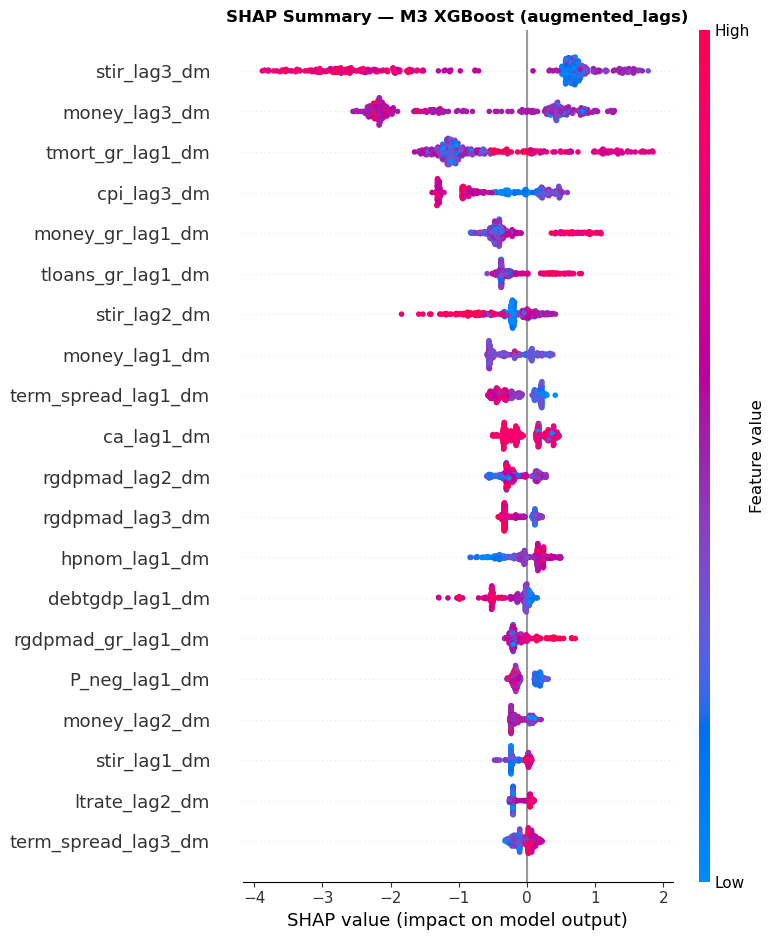

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/shap_summary_m3.png


In [32]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_m3, feature_names=M3_FEATURES,
                  show=False, plot_type='dot')
plt.title('SHAP Summary — M3 XGBoost (augmented_lags)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/shap_summary_m3.png')

## Cell 16 — SHAP Importance by Lag Depth

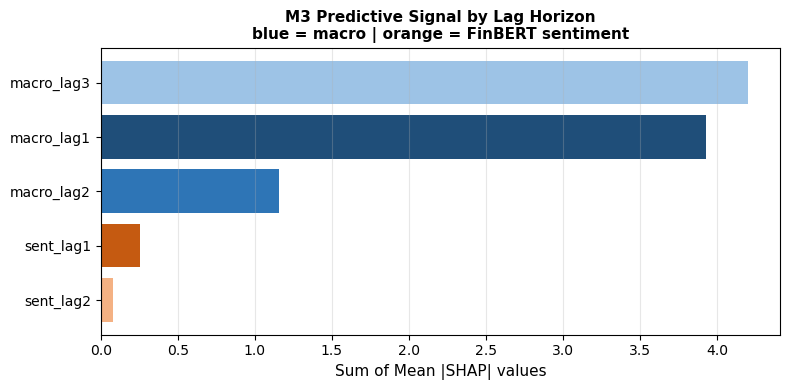

Lag depth importance:
macro_lag3    4.197361
macro_lag1    3.929705
macro_lag2    1.153973
sent_lag1     0.257590
sent_lag2     0.080605

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/shap_by_lag_depth.png


In [34]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=M3_FEATURES)

lag_importance = {
    grp: mean_abs_shap[[c for c in cols if c in mean_abs_shap.index]].sum()
    for grp, cols in LAG_GROUPS.items()
}
lag_series = pd.Series(lag_importance).sort_values(ascending=False)

palette = {'macro_lag1':'#1F4E79', 'macro_lag2':'#2E75B6', 'macro_lag3':'#9DC3E6',
           'sent_lag1':'#C55A11',  'sent_lag2':'#F4B183'}

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(lag_series.index[::-1], lag_series.values[::-1],
        color=[palette.get(g, '#999') for g in lag_series.index[::-1]])
ax.set_xlabel('Sum of Mean |SHAP| values', fontsize=11)
ax.set_title('M3 Predictive Signal by Lag Horizon\n'
             'blue = macro | orange = FinBERT sentiment', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_by_lag_depth.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lag depth importance:')
print(lag_series.to_string())
print(f'\nSaved → {FIG_DIR}/shap_by_lag_depth.png')

## Cell 17 — Per-Fold SHAP Stability (mean ± std across folds)

Computing per-fold SHAP stability (3-5 minutes)...
  Fold 2007: 18 obs
  Fold 2008: 18 obs
  Fold 2009: 18 obs
  Fold 2010: 18 obs
  Fold 2011: 18 obs
  Fold 2012: 18 obs
  Fold 2013: 18 obs
  Fold 2014: 18 obs
  Fold 2015: 18 obs
  Fold 2016: 18 obs
  Fold 2017: 18 obs
  Fold 2018: 17 obs


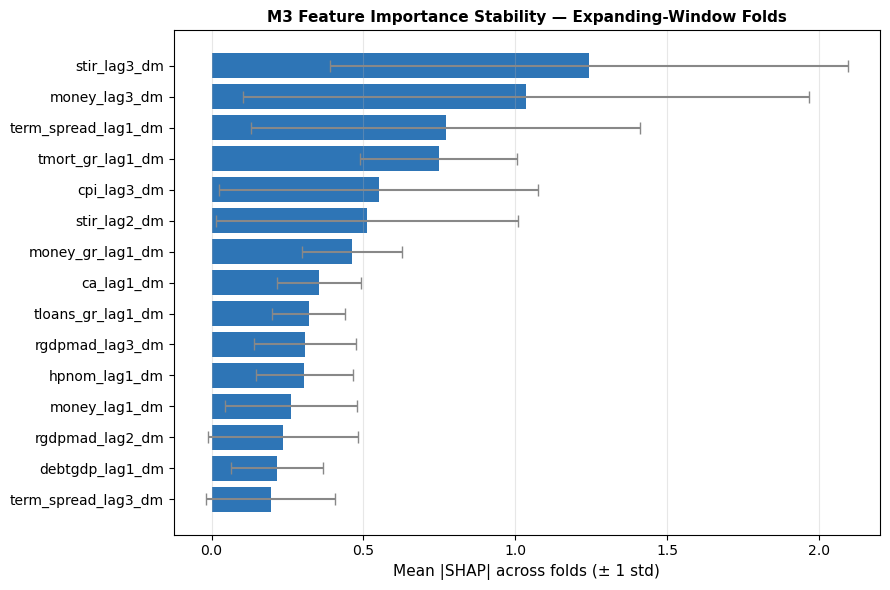

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_lags/shap_fold_stability.png


In [36]:
print('Computing per-fold SHAP stability (3-5 minutes)...')

years_cv   = sorted(y for y in df_model['year'].unique() if y not in [2019, 2020])
first_eval = years_cv[7]
fold_shap_list = []

for eval_yr in (y for y in years_cv if y >= first_eval):
    tr = df_model['year'] < eval_yr
    te = df_model['year'] == eval_yr
    X_tr = df_model.loc[tr, M3_FEATURES]
    y_tr = df_model.loc[tr, TARGET]
    X_te = df_model.loc[te, M3_FEATURES]

    if y_tr.sum() == 0 or len(X_te) == 0:
        continue

    m = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           scale_pos_weight=scale_pw, random_state=RANDOM_STATE,
                           eval_metric='logloss', verbosity=0)
    m.fit(X_tr, y_tr)

    tmp2 = tempfile.mktemp(suffix='.json')
    m.save_model(tmp2); m.load_model(tmp2); os.remove(tmp2)

    sv = shap.TreeExplainer(m).shap_values(X_te)
    fold_shap_list.append(pd.Series(np.abs(sv).mean(axis=0), index=M3_FEATURES))
    print(f'  Fold {eval_yr}: {len(X_te)} obs')

shap_stab = pd.DataFrame(fold_shap_list)
shap_mean = shap_stab.mean().sort_values(ascending=False)
shap_std  = shap_stab.std()

top15 = shap_mean.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index[::-1], top15.values[::-1],
        xerr=shap_std[top15.index[::-1]].values,
        color='#2E75B6', ecolor='#888', capsize=4)
ax.set_xlabel('Mean |SHAP| across folds (± 1 std)', fontsize=11)
ax.set_title('M3 Feature Importance Stability — Expanding-Window Folds',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_fold_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/shap_fold_stability.png')

## Cell 18 — Save All Outputs

In [38]:
# Save modelling dataset and feature lists
df_model.to_csv(OUT_DIR / 'df_model_aug.csv', index=False)
pd.Series(M1_FEATURES).to_csv(OUT_DIR / 'M1_features.csv', index=False, header=False)
pd.Series(M2_FEATURES).to_csv(OUT_DIR / 'M2_features.csv', index=False, header=False)
pd.Series(M3_FEATURES).to_csv(OUT_DIR / 'M3_features.csv', index=False, header=False)

# Save OOS predictions aligned to df_model index
oos_m1 = pd.Series(prob_m1, index=idx_m1, name='prob_m1')
oos_m2 = pd.Series(prob_m2, index=idx_m2, name='prob_m2')
oos_m3 = pd.Series(prob_m3, index=idx_m3, name='prob_m3')
oos_all = df_model[['year', 'iso', TARGET]].join(oos_m1).join(oos_m2).join(oos_m3)
oos_all.to_csv(OUT_DIR / 'oos_predictions.csv', index=False)

print('=' * 65)
print(' NOTEBOOK 05 augmented_lags COMPLETE')
print('=' * 65)
print()
print(f'Crisis events modelled : {int(df_model[TARGET].sum())} (crisis_w2)')
print(f'Model rows             : {len(df_model)}')
print(f'Year range             : {df_model["year"].min()} – {df_model["year"].max()}')
print()
print('CSV outputs:')
for f in sorted(OUT_DIR.glob('*.csv')):
    print(f'  {f.name}  ({f.stat().st_size//1024} KB)')
print()
print('Figures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}  ({f.stat().st_size//1024} KB)')
print()
print('Ready to run 06_Results_Analysis_augmented_lags.ipynb')

 NOTEBOOK 05 augmented_lags COMPLETE

Crisis events modelled : 39 (crisis_w2)
Model rows             : 372
Year range             : 2000 – 2020

CSV outputs:
  df_model_aug.csv  (840 KB)
  M1_features.csv  (0 KB)
  M2_features.csv  (0 KB)
  M3_features.csv  (0 KB)
  model_results.csv  (0 KB)
  oos_predictions.csv  (17 KB)
  shap_values_m3.csv  (200 KB)

Figures:
  roc_pr_curves.png  (113 KB)
  shap_by_lag_depth.png  (38 KB)
  shap_fold_stability.png  (78 KB)
  shap_summary_m3.png  (235 KB)

Ready to run 06_Results_Analysis_augmented_lags.ipynb
